# Testing de modelos en set de test

Este notebook permite evaluar y comparar modelos de distintos algoritmos
guardados como pipelines del proyecto (LightGBM, RandomForest, XGBoost, Árbol de Decisiones).

## Flujo

1. Detectar o elegir estudios/modelos por algoritmo.
2. Cargar test en formato sparse desde `datasets/final_sparse`.
3. Evaluar cada modelo y comparar metricas globales.
4. Ver matriz de confusion y reporte por clase para un algoritmo.

In [1]:
from pathlib import Path
from typing import Dict, Optional, Any
import json

import joblib
import numpy as np
import optuna
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix
from sparse_dataset import load_sparse_split, load_feature_columns

from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
)

/home/francisco/miniconda3/envs/tesis311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Ajustes base
ROOT = Path('.').resolve()
DATASET_DIR = ROOT / 'datasets'
SPARSE_DIR = DATASET_DIR / 'final_sparse'
TEST_SPLIT = 'test'
CLASS_MAP_PATH = DATASET_DIR / 'class_mapping.json'
OPTUNA_DB = 'sqlite:///optuna.sqlite3'

ALGO_DIRS = {
    'lightgbm': ROOT / 'models' / 'lgbm',
    'randomforest': ROOT / 'models' / 'randomforest',
    'xgboost': ROOT / 'models' / 'xgboost',
    'decision_tree': ROOT / 'models' / 'decision_tree',
}

STUDY_PREFIXES = {
    'lightgbm': ['LGBM_', 'lightgbm_'],
    'randomforest': ['RF_', 'randomforest_'],
    'xgboost': ['xgboost_', 'XGBOOST_'],
    'decision_tree': ['dt_', 'decision_tree_'],
}

print('ROOT:', ROOT)
print('SPARSE_DIR exists:', SPARSE_DIR.exists())
print('test_X exists:', (SPARSE_DIR / 'test_X.npz').exists())
print('test_y exists:', (SPARSE_DIR / 'test_y.npy').exists())

ROOT: /home/francisco/maestrìa/trabajo final/tf-austral
SPARSE_DIR exists: True
test_X exists: True
test_y exists: True


In [3]:
def invert_class_mapping(path: Path) -> Dict[int, str]:
    if not path.exists():
        return {}
    raw = json.loads(path.read_text(encoding='utf-8'))
    return {int(v): str(k) for k, v in raw.items()}


def list_studies_by_algo(storage_url: str) -> Dict[str, list]:
    studies = optuna.get_all_study_summaries(storage=storage_url)
    result = {k: [] for k in ALGO_DIRS.keys()}

    for s in studies:
        for algo, prefixes in STUDY_PREFIXES.items():
            if any(s.study_name.startswith(p) for p in prefixes):
                result[algo].append(s)
                break

    for algo in result:
        result[algo] = sorted(
            result[algo],
            key=lambda x: (x.best_trial.value if x.best_trial else -10**9),
            reverse=True,
        )

    return result


def strip_prefix(study_name: str, algo: str) -> str:
    for prefix in STUDY_PREFIXES[algo]:
        if study_name.startswith(prefix):
            return study_name[len(prefix):]
    return study_name


def find_model_path(algo: str, short_study_name: str) -> Optional[Path]:
    model_root = ALGO_DIRS[algo]
    if not model_root.exists():
        return None

    expected = model_root / short_study_name / f'model_{short_study_name}.pkl'
    if expected.exists():
        return expected

    candidates = sorted(model_root.rglob('model_*.pkl'), key=lambda p: p.stat().st_mtime, reverse=True)
    if not candidates:
        return None

    for c in candidates:
        if short_study_name.lower() in c.stem.lower():
            return c

    return candidates[0]


def choose_study_and_model(algo: str, manual_short_study: Optional[str], studies_cache: Dict[str, list]):
    if manual_short_study:
        model_path = find_model_path(algo, manual_short_study)
        return manual_short_study, model_path

    studies = studies_cache.get(algo, [])
    if studies:
        short_study = strip_prefix(studies[0].study_name, algo)
        model_path = find_model_path(algo, short_study)
        return short_study, model_path

    model_root = ALGO_DIRS[algo]
    if not model_root.exists():
        return None, None

    candidates = sorted(model_root.rglob('model_*.pkl'), key=lambda p: p.stat().st_mtime, reverse=True)
    if not candidates:
        return None, None

    last = candidates[0]
    short_study = last.stem.replace('model_', '', 1)
    return short_study, last

In [4]:
# Opcional: fijar estudios manualmente (None = autodeteccion)
study_name = "final"
MANUAL_STUDIES = {
    'lightgbm': "LGBM_final",
    'randomforest': "RF_final",
    'xgboost': "xgboost_final",
    'decision_tree': "dt_final",
}

studies_cache = list_studies_by_algo(OPTUNA_DB)

for algo in ALGO_DIRS.keys():
    best = studies_cache.get(algo, [])
    msg = best[0].study_name if best else 'sin estudio en optuna'
    print(f'{algo:12s} -> {msg}')

lightgbm     -> LGBM_final
randomforest -> RF_final
xgboost      -> xgboost_final
decision_tree -> dt_modelo_completo_final


In [5]:
if not SPARSE_DIR.exists():
    raise FileNotFoundError(f'No existe {SPARSE_DIR}')

X_test, y_test_np = load_sparse_split(DATASET_DIR, TEST_SPLIT)
if not isinstance(X_test, csr_matrix):
    X_test = X_test.tocsr()

feature_columns = load_feature_columns(DATASET_DIR)
if X_test.shape[1] != len(feature_columns):
    raise ValueError(
        f'Dimension inconsistente: X_test tiene {X_test.shape[1]} columnas y feature_columns tiene {len(feature_columns)}'
    )

y_test = pd.Series(y_test_np).astype(int)
inv_mapping = invert_class_mapping(CLASS_MAP_PATH)

print('X_test shape:', X_test.shape)
print('y_test clases:', y_test.nunique())
print('feature_columns:', len(feature_columns))

X_test shape: (25357, 3172)
y_test clases: 13
feature_columns: 3172


In [6]:
def evaluate_pipeline(algo: str, model_path: Path, X: Any, y: pd.Series):
    model = joblib.load(model_path)
    y_pred = pd.Series(np.asarray(model.predict(X)).ravel()).astype(int)

    metrics = {
        'algorithm': algo,
        'model_path': str(model_path),
        'accuracy': accuracy_score(y, y_pred),
        'kappa': cohen_kappa_score(y, y_pred),
        'f1_macro': f1_score(y, y_pred, average='macro', zero_division=0),
        'precision_macro': precision_score(y, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y, y_pred, average='macro', zero_division=0),
    }

    labels = sorted(set(y.unique()).union(set(y_pred.unique())))
    cm = confusion_matrix(y, y_pred, labels=labels)

    return metrics, y_pred, labels, cm


# Crear mapeo de números a nombres de clases
with open(CLASS_MAP_PATH, 'r') as f:
    class_mapping = json.load(f)
class_names_dict = {v: k for k, v in class_mapping.items()}

results_rows = []
predictions_by_algo = {}
cm_by_algo = {}
labels_by_algo = {}

for algo in ALGO_DIRS.keys():
    short_study, model_path = choose_study_and_model(algo, MANUAL_STUDIES.get(algo), studies_cache)

    if model_path is None or not Path(model_path).exists():
        print(f'[SKIP] {algo}: no se encontro modelo para evaluar')
        continue

    print(f'[RUN ] {algo}: {short_study} -> {model_path}')
    metrics, y_pred, labels, cm = evaluate_pipeline(algo, Path(model_path), X_test, y_test)
    metrics['study_name'] = short_study

    results_rows.append(metrics)
    predictions_by_algo[algo] = y_pred
    cm_by_algo[algo] = cm
    labels_by_algo[algo] = labels

results_df = pd.DataFrame(results_rows)
if results_df.empty:
    raise RuntimeError('No hubo modelos evaluados. Revisar MANUAL_STUDIES o carpetas de models/.')

results_df = results_df.sort_values(['kappa', 'accuracy'], ascending=False).reset_index(drop=True)

# Mostrar resultados con mejor formato
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
print("\n" + "="*100)
print("RESULTADOS DE EVALUACIÓN EN TEST SET")
print("="*100)
print(results_df[['algorithm', 'study_name', 'accuracy', 'kappa', 'f1_macro', 'precision_macro', 'recall_macro']].to_string(index=True))
print("="*100)
results_df

[RUN ] lightgbm: LGBM_final -> /home/francisco/maestrìa/trabajo final/tf-austral/models/lgbm/final/model_final.pkl
[LightGBM] [Warning] Unknown parameter: verbose_eval


/home/francisco/miniconda3/envs/tesis311/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[RUN ] randomforest: RF_final -> /home/francisco/maestrìa/trabajo final/tf-austral/models/randomforest/final/model_final.pkl
[RUN ] xgboost: xgboost_final -> /home/francisco/maestrìa/trabajo final/tf-austral/models/xgboost/final/model_final.pkl
[RUN ] decision_tree: dt_final -> /home/francisco/maestrìa/trabajo final/tf-austral/models/decision_tree/final/model_final.pkl

RESULTADOS DE EVALUACIÓN EN TEST SET
       algorithm     study_name  accuracy     kappa  f1_macro  precision_macro  recall_macro
0        xgboost  xgboost_final  0.966794  0.958212  0.951013         0.950625      0.952794
1       lightgbm     LGBM_final  0.966715  0.958138  0.947615         0.947134      0.950387
2   randomforest       RF_final  0.958276  0.947469  0.938799         0.944224      0.937630
3  decision_tree       dt_final  0.927752  0.908138  0.909798         0.927360      0.897849


,algorithm,model_path,accuracy,kappa,f1_macro,precision_macro,recall_macro,study_name
0,xgboost,/home/francisco/maestrìa/trabajo final/tf-aust...,0.966794,0.958212,0.951013,0.950625,0.952794,xgboost_final
1,lightgbm,/home/francisco/maestrìa/trabajo final/tf-aust...,0.966715,0.958138,0.947615,0.947134,0.950387,LGBM_final
2,randomforest,/home/francisco/maestrìa/trabajo final/tf-aust...,0.958276,0.947469,0.938799,0.944224,0.937630,RF_final
3,decision_tree,/home/francisco/maestrìa/trabajo final/tf-aust...,0.927752,0.908138,0.909798,0.927360,0.897849,dt_final


Algoritmo seleccionado: xgboost


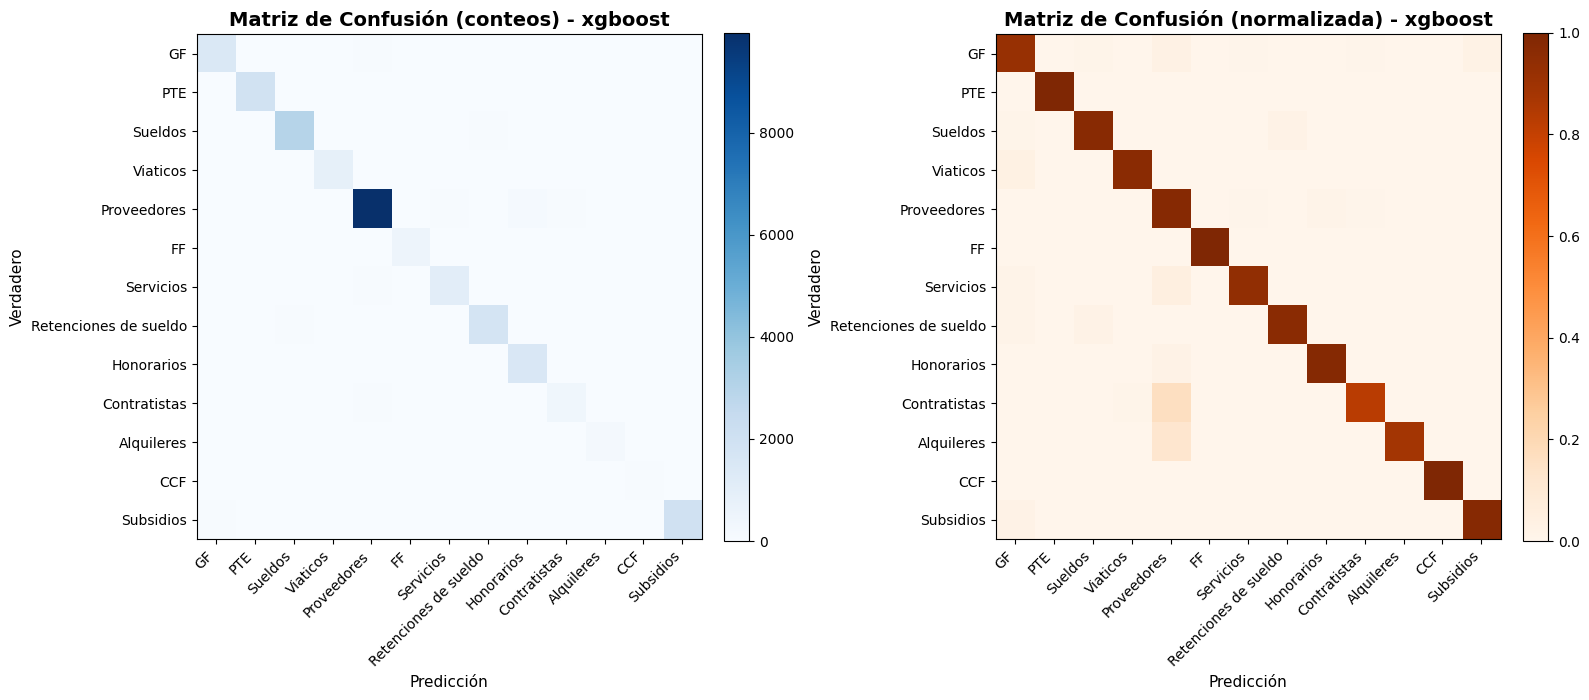


REPORTE DE CLASIFICACIÓN - XGBOOST
                       precision    recall  f1-score       support
GF                      0.905934  0.921053  0.913431   1558.000000
PTE                     1.000000  1.000000  1.000000   1885.000000
Sueldos                 0.978375  0.966030  0.972163   3091.000000
Viaticos                0.983778  0.962585  0.973066    882.000000
Proveedores             0.976183  0.975419  0.975801  10211.000000
FF                      1.000000  1.000000  1.000000    473.000000
Servicios               0.942081  0.940379  0.941230   1107.000000
Retenciones de sueldo   0.961075  0.963716  0.962394   1819.000000
Honorarios              0.923926  0.976654  0.949559   1542.000000
Contratistas            0.866370  0.825902  0.845652    471.000000
Alquileres              0.976959  0.879668  0.925764    241.000000
CCF                     0.862745  1.000000  0.926316     44.000000
Subsidios               0.980703  0.974914  0.977800   2033.000000
accuracy                0.

,precision,recall,f1-score,support
GF,0.905934,0.921053,0.913431,1558.000000
PTE,1.000000,1.000000,1.000000,1885.000000
Sueldos,0.978375,0.966030,0.972163,3091.000000
Viaticos,0.983778,0.962585,0.973066,882.000000
Proveedores,0.976183,0.975419,0.975801,10211.000000
FF,1.000000,1.000000,1.000000,473.000000
Servicios,0.942081,0.940379,0.941230,1107.000000
Retenciones de sueldo,0.961075,0.963716,0.962394,1819.000000
Honorarios,0.923926,0.976654,0.949559,1542.000000
Contratistas,0.866370,0.825902,0.845652,471.000000


In [7]:
# Elegir algoritmo para analisis detallado
ALGO_DETAIL = results_df.loc[0, 'algorithm']
print('Algoritmo seleccionado:', ALGO_DETAIL)

y_pred_detail = predictions_by_algo[ALGO_DETAIL]
labels = labels_by_algo[ALGO_DETAIL]
cm = cm_by_algo[ALGO_DETAIL]

# Usar nombres de clases del mapping
label_names = [class_names_dict.get(int(lbl), f"Clase_{lbl}") for lbl in labels]

cm_norm = cm.astype(float) / np.clip(cm.sum(axis=1, keepdims=True), 1, None)

fig, ax = plt.subplots(1, 2, figsize=(16, 7))

im0 = ax[0].imshow(cm, cmap='Blues')
ax[0].set_title(f'Matriz de Confusión (conteos) - {ALGO_DETAIL}', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Predicción', fontsize=11)
ax[0].set_ylabel('Verdadero', fontsize=11)
ax[0].set_xticks(np.arange(len(label_names)))
ax[0].set_yticks(np.arange(len(label_names)))
ax[0].set_xticklabels(label_names, rotation=45, ha='right', fontsize=10)
ax[0].set_yticklabels(label_names, fontsize=10)
plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

im1 = ax[1].imshow(cm_norm, cmap='Oranges', vmin=0, vmax=1)
ax[1].set_title(f'Matriz de Confusión (normalizada) - {ALGO_DETAIL}', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Predicción', fontsize=11)
ax[1].set_ylabel('Verdadero', fontsize=11)
ax[1].set_xticks(np.arange(len(label_names)))
ax[1].set_yticks(np.arange(len(label_names)))
ax[1].set_xticklabels(label_names, rotation=45, ha='right', fontsize=10)
ax[1].set_yticklabels(label_names, fontsize=10)
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# Reporte de clasificación con nombres de clases
report = classification_report(y_test, y_pred_detail, target_names=label_names, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T

print("\n" + "="*80)
print(f"REPORTE DE CLASIFICACIÓN - {ALGO_DETAIL.upper()}")
print("="*80)
print(report_df.to_string())
print("="*80)

report_df

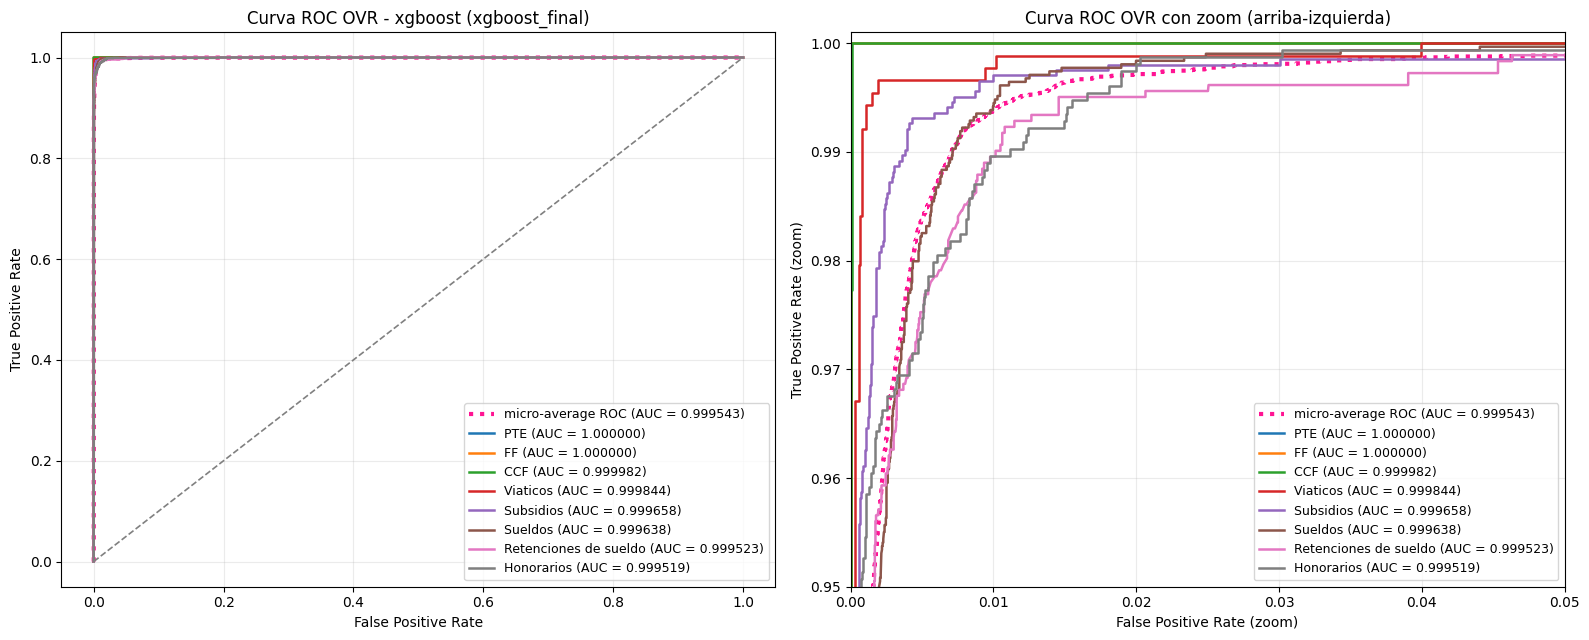


AUC micro-average: 0.999543

AUC por Clase:
                clase      auc
                  PTE 1.000000
                   FF 1.000000
                  CCF 0.999982
             Viaticos 0.999844
            Subsidios 0.999658
              Sueldos 0.999638
Retenciones de sueldo 0.999523
           Honorarios 0.999519
            Servicios 0.999236
           Alquileres 0.998715
          Proveedores 0.998523
                   GF 0.997114
         Contratistas 0.996999


In [8]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Cargar mapeo de clases
CLASS_MAP_PATH = DATASET_DIR / 'class_mapping.json'
with open(CLASS_MAP_PATH, 'r') as f:
    class_mapping = json.load(f)
class_names_dict = {v: k for k, v in class_mapping.items()}

# Recuperar el modelo elegido en el ranking
algo_roc = ALGO_DETAIL
short_study_roc, model_path_roc = choose_study_and_model(
    algo_roc, MANUAL_STUDIES.get(algo_roc), studies_cache
)

if model_path_roc is None or not Path(model_path_roc).exists():
    raise FileNotFoundError(f'No se encontro modelo para ROC: {algo_roc}')

model_roc = joblib.load(model_path_roc)

if not hasattr(model_roc, 'predict_proba'):
    raise AttributeError(
        f'El modelo {algo_roc} no expone predict_proba, no se puede construir ROC.'
    )

y_score = np.asarray(model_roc.predict_proba(X_test))
classes = np.unique(y_test)

if y_score.ndim != 2 or y_score.shape[1] != len(classes):
    raise ValueError(
        f'Dimension inesperada en predict_proba: {y_score.shape}, clases esperadas={len(classes)}'
    )

# Ventana de zoom para resaltar diferencias finas
zoom_fpr_max = 0.05
zoom_tpr_min = 0.95

# ROC binaria (si hay dos clases)
if len(classes) == 2:
    positive_class = classes[1]
    positive_class_name = class_names_dict.get(int(positive_class), f"Clase_{positive_class}")
    y_true_bin = (y_test.to_numpy() == positive_class).astype(int)
    fpr, tpr, _ = roc_curve(y_true_bin, y_score[:, 1])
    roc_auc = auc(fpr, tpr)

    fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))

    # Vista completa
    ax[0].plot(fpr, tpr, lw=2, label=f'ROC (AUC = {roc_auc:.6f})')
    ax[0].plot([0, 1], [0, 1], '--', color='gray', lw=1.2)
    ax[0].set_xlabel('False Positive Rate')
    ax[0].set_ylabel('True Positive Rate')
    ax[0].set_title(f'ROC completa - {algo_roc} ({short_study_roc})')
    ax[0].legend(loc='lower right')
    ax[0].grid(alpha=0.25)

    # Vista zoom
    ax[1].plot(fpr, tpr, lw=2, label=f'ROC (AUC = {roc_auc:.6f})')
    ax[1].plot([0, 1], [0, 1], '--', color='gray', lw=1.2)
    ax[1].set_xlim(0.0, zoom_fpr_max)
    ax[1].set_ylim(zoom_tpr_min, 1.001)
    ax[1].set_xlabel('False Positive Rate (zoom)')
    ax[1].set_ylabel('True Positive Rate (zoom)')
    ax[1].set_title('ROC con zoom (arriba-izquierda)')
    ax[1].legend(loc='lower right')
    ax[1].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

    print(f'AUC binaria ({positive_class_name}): {roc_auc:.6f}')

# ROC multiclase OVR: curvas por clase + micro-average
else:
    y_true_bin = label_binarize(y_test.to_numpy(), classes=classes)

    fpr = {}
    tpr = {}
    roc_auc = {}

    for i, cls in enumerate(classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    fpr['micro'], tpr['micro'], _ = roc_curve(y_true_bin.ravel(), y_score.ravel())
    roc_auc['micro'] = auc(fpr['micro'], tpr['micro'])

    top_n = min(8, len(classes))
    top_classes = sorted(classes, key=lambda c: roc_auc[int(np.where(classes == c)[0][0])], reverse=True)[:top_n]

    fig, ax = plt.subplots(1, 2, figsize=(16, 6.5))

    # Vista completa
    ax[0].plot(
        fpr['micro'],
        tpr['micro'],
        label=f"micro-average ROC (AUC = {roc_auc['micro']:.6f})",
        color='deeppink',
        linestyle=':',
        linewidth=3,
    )
    for cls in top_classes:
        idx = int(np.where(classes == cls)[0][0])
        class_name = class_names_dict.get(int(cls), f"Clase_{cls}")
        ax[0].plot(
            fpr[idx],
            tpr[idx],
            lw=1.8,
            label=f'{class_name} (AUC = {roc_auc[idx]:.6f})'
        )
    ax[0].plot([0, 1], [0, 1], '--', color='gray', lw=1.2)
    ax[0].set_xlabel('False Positive Rate')
    ax[0].set_ylabel('True Positive Rate')
    ax[0].set_title(f'Curva ROC OVR - {algo_roc} ({short_study_roc})')
    ax[0].legend(loc='lower right', fontsize=9)
    ax[0].grid(alpha=0.25)

    # Vista zoom
    ax[1].plot(
        fpr['micro'],
        tpr['micro'],
        label=f"micro-average ROC (AUC = {roc_auc['micro']:.6f})",
        color='deeppink',
        linestyle=':',
        linewidth=3,
    )
    for cls in top_classes:
        idx = int(np.where(classes == cls)[0][0])
        class_name = class_names_dict.get(int(cls), f"Clase_{cls}")
        ax[1].plot(
            fpr[idx],
            tpr[idx],
            lw=1.8,
            label=f'{class_name} (AUC = {roc_auc[idx]:.6f})'
        )
    ax[1].plot([0, 1], [0, 1], '--', color='gray', lw=1.2)
    ax[1].set_xlim(0.0, zoom_fpr_max)
    ax[1].set_ylim(zoom_tpr_min, 1.001)
    ax[1].set_xlabel('False Positive Rate (zoom)')
    ax[1].set_ylabel('True Positive Rate (zoom)')
    ax[1].set_title('Curva ROC OVR con zoom (arriba-izquierda)')
    ax[1].legend(loc='lower right', fontsize=9)
    ax[1].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

    auc_rows = [
        {'clase': class_names_dict.get(int(cls), f"Clase_{cls}"), 'auc': float(roc_auc[i])}
        for i, cls in enumerate(classes)
    ]
    auc_df = pd.DataFrame(auc_rows).sort_values('auc', ascending=False).reset_index(drop=True)
    print(f"\nAUC micro-average: {roc_auc['micro']:.6f}")
    print("\nAUC por Clase:")
    print(auc_df.to_string(index=False))
    auc_df

[OK] lightgbm: 3172 features extraídas
[OK] randomforest: 3172 features extraídas
[OK] xgboost: 3172 features extraídas
[OK] decision_tree: 3172 features extraídas


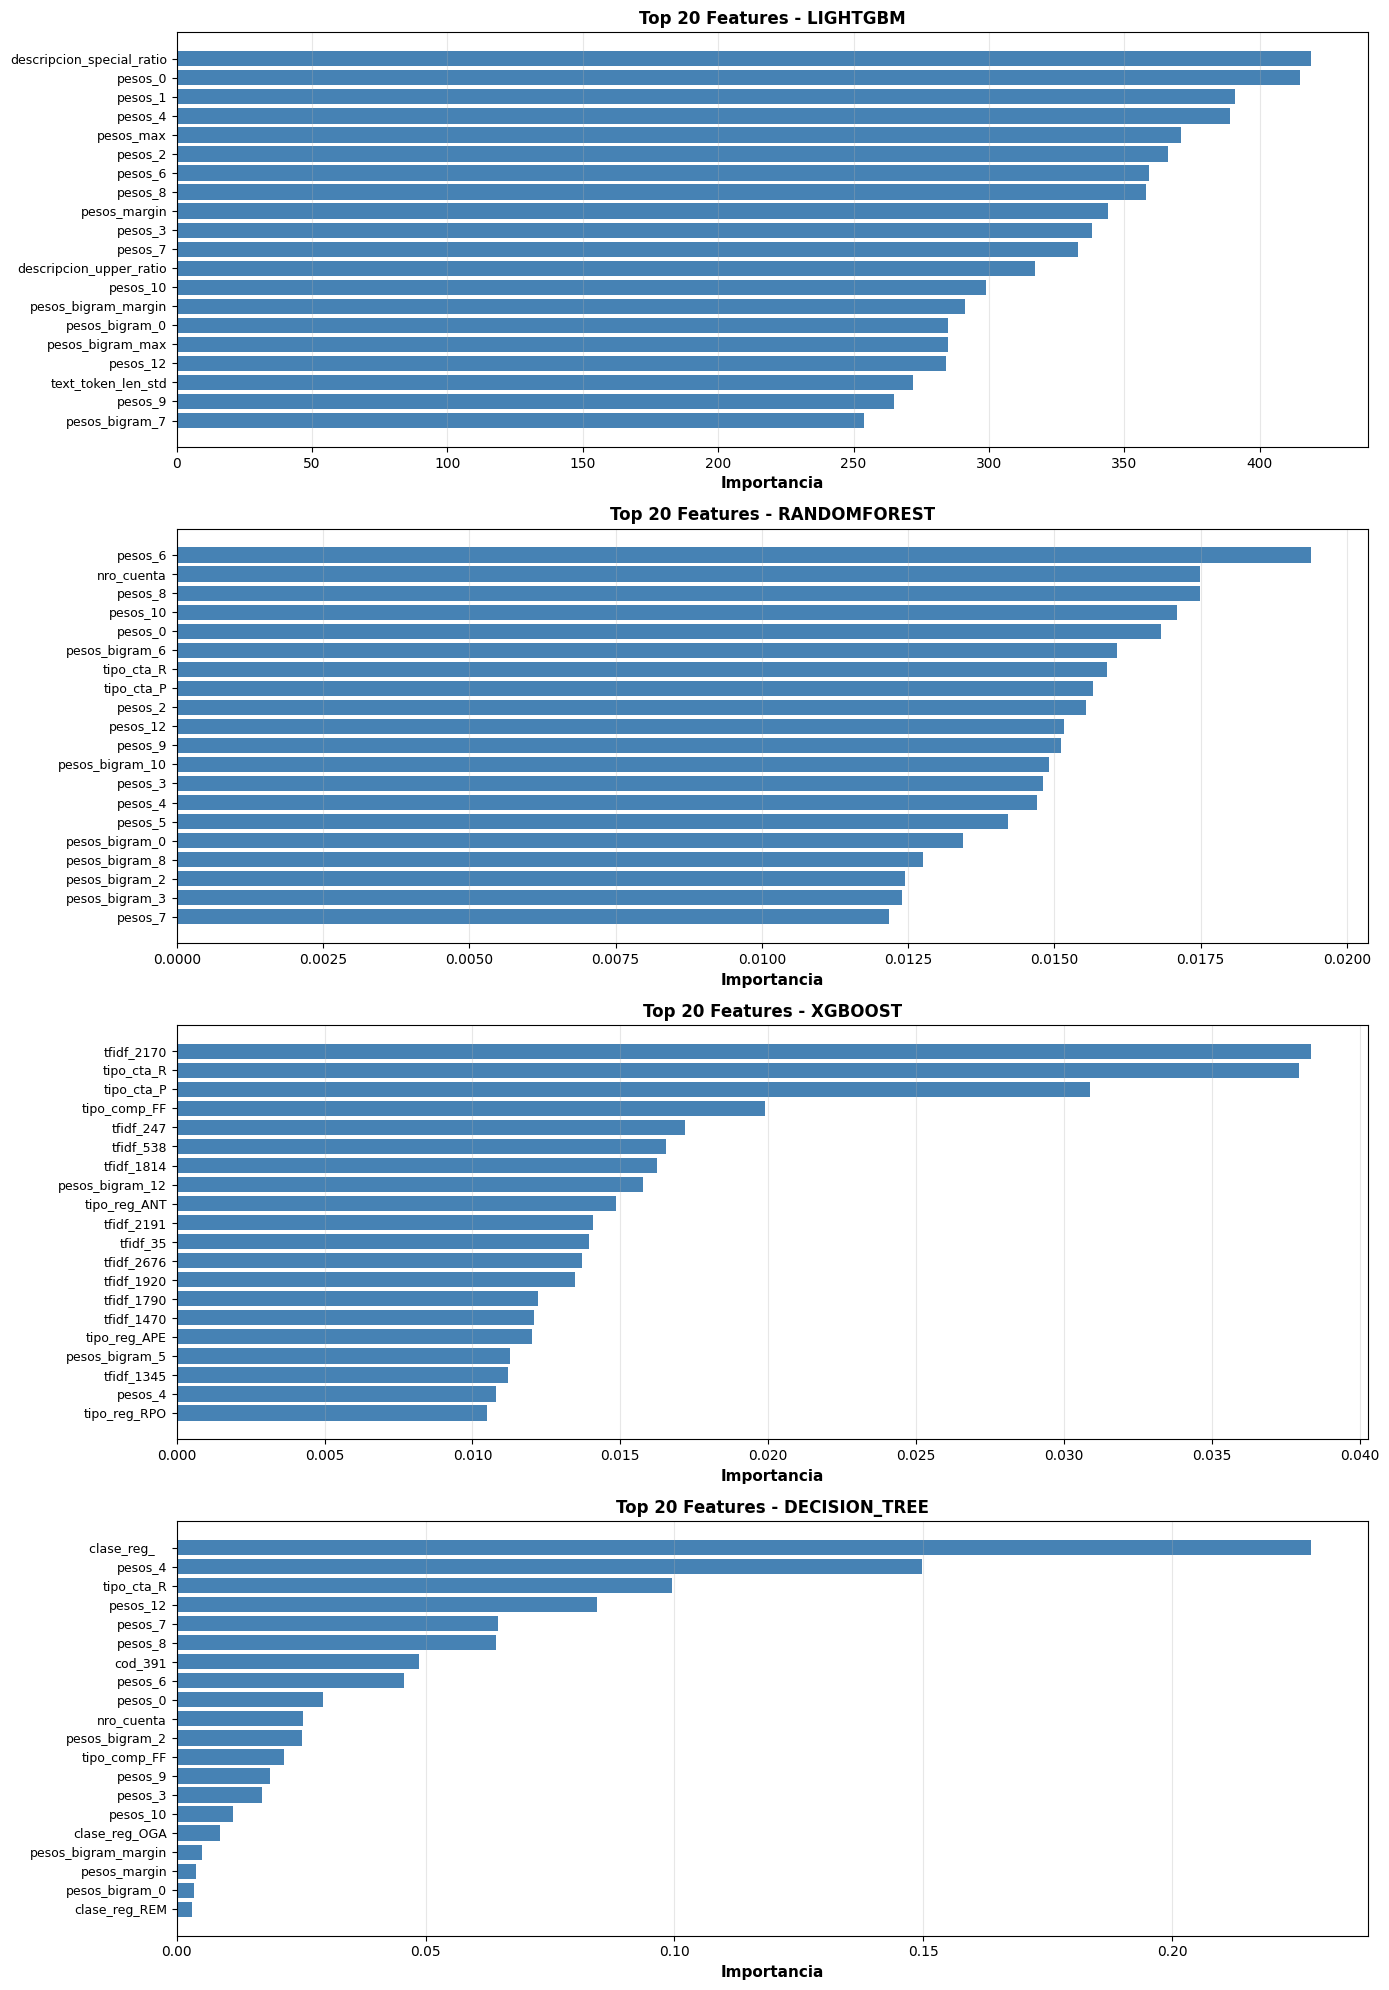


TOP 20 FEATURES POR MODELO

DECISION_TREE:
--------------------------------------------------------------------------------
            feature importance
      clase_reg_      0.227882
            pesos_4   0.149657
         tipo_cta_R   0.099492
           pesos_12   0.084517
            pesos_7   0.064573
            pesos_8   0.064072
            cod_391   0.048667
            pesos_6   0.045749
            pesos_0   0.029338
         nro_cuenta   0.025313
     pesos_bigram_2   0.025136
       tipo_comp_FF   0.021581
            pesos_9   0.018750
            pesos_3   0.017149
           pesos_10   0.011337
      clase_reg_OGA   0.008601
pesos_bigram_margin   0.005066
       pesos_margin   0.003809
     pesos_bigram_0   0.003433
      clase_reg_REM   0.003116

LIGHTGBM:
--------------------------------------------------------------------------------
                  feature importance
descripcion_special_ratio 419.000000
                  pesos_0 415.000000
                  pes

FileNotFoundError: [Errno 2] No such file or directory: '/home/francisco/maestria/trabajo_final/envios_profesor/importancia_1.png'

In [11]:
# Feature Importance de todos los modelos
feature_importance_all = {}
n_top_features = 20

for algo in ALGO_DIRS.keys():
    short_study, model_path = choose_study_and_model(
        algo, MANUAL_STUDIES.get(algo), studies_cache
    )
    
    if model_path is None or not Path(model_path).exists():
        print(f'[SKIP] {algo}: no se encontro modelo')
        continue
    
    try:
        model = joblib.load(model_path)
        
        if not hasattr(model, 'feature_importances_'):
            print(f'[SKIP] {algo}: no tiene atributo feature_importances_')
            continue
        
        feature_imp = model.feature_importances_
        
        # Crear DataFrame con feature importance
        imp_df = pd.DataFrame({
            'feature': feature_columns,
            'importance': feature_imp
        }).sort_values('importance', ascending=False)
        
        feature_importance_all[algo] = imp_df
        print(f'[OK] {algo}: {len(imp_df)} features extraídas')
        
    except Exception as e:
        print(f'[ERROR] {algo}: {e}')

# Visualizar feature importance para cada modelo
n_algos = len(feature_importance_all)
if n_algos > 0:
    fig, axes = plt.subplots(n_algos, 1, figsize=(14, 5 * n_algos))
    if n_algos == 1:
        axes = [axes]
    
    for idx, (algo, imp_df) in enumerate(feature_importance_all.items()):
        top_features = imp_df.head(n_top_features)
        
        axes[idx].barh(range(len(top_features)), top_features['importance'].values, color='steelblue')
        axes[idx].set_yticks(range(len(top_features)))
        axes[idx].set_yticklabels(top_features['feature'].values, fontsize=9)
        axes[idx].set_xlabel('Importancia', fontsize=11, fontweight='bold')
        axes[idx].set_title(f'Top {n_top_features} Features - {algo.upper()}', fontsize=12, fontweight='bold')
        axes[idx].invert_yaxis()
        axes[idx].grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Mostrar tablas de top features por modelo
print("\n" + "="*100)
print("TOP 20 FEATURES POR MODELO")
print("="*100)
for algo, imp_df in sorted(feature_importance_all.items()):
    print(f"\n{algo.upper()}:")
    print("-" * 80)
    top_20 = imp_df.head(n_top_features)[['feature', 'importance']]
    top_20['importance'] = top_20['importance'].apply(lambda x: f"{x:.6f}")
    print(top_20.to_string(index=False))
print("="*100)
fig.savefig("/home/francisco/maestria/trabajo_final/envios_profesor/importancia_1.png", dpi=300, bbox_inches='tight')